In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [16]:
import pickle
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from src.Utils import *
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, accuracy_score, roc_curve, auc, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Importamos los Datos

In [4]:
# Abre el archivo en modo lectura binaria ('rb')
with open('../data/bank_12.pkl', 'rb') as archivo:
    df = pickle.load(archivo)

C:\Users\aleja\AppData\Local\Temp\ipykernel_39320\4250435786.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(archivo)


# Preprocesado

## Feature Engineering

### Pdays
Para empezar con el preprocesado, primero vamos a hacer un poco de feature engineering con la variable pdays:

Vamos a crear un nuevo atributo **wasContacted** que valga 0 si el contacto es desconcocido y 1 en caso contrario.

Además, vamos a aplicar una categorización sobre pdays de manera que vamos a obtener un nuevo atributo ordinal **pdaysTransformed** que va a valer:
+ 0 si el contacto fue desconocido
+ 1 si el contacto fue inferior a 100 días
+ 2 si el contacto fue inferior a 200 días
+ 3 si el contacto fue inferior a 400 días
+ 4 si el contacto fue superior a 400 días

Otra transformación que se podría hacer sobre esta variable es crear un nuevo atributo donde los valores -1 se sustituyen por el máximo valor conocido de pdays.

In [5]:
pdays_transformer = FunctionTransformer(process_pdays)

### Poutcome

En el apartado de **'Insights de Árboles Poco Profundos'** se explica con más detenimiento este intento de feature.

In [6]:
poutcome_transformer = FunctionTransformer(process_poutcome)

### Asimetría Numérica (Skewness) en Duration y Balance

Otra de las cuestiones matemáticas que arrastramos desde el EDA es el tratamiento de la fuerte asimetría (*Skewness*) presente en algunas variables continuas críticas.

Atributos como `duration` (duración del contacto telefónico) y `balance` (saldo de la cuenta) están lejos de comportarse como distribuciones normales (campanas de Gauss pura). En su lugar, presentan densas acumulaciones cerca de cero y "colas" larguísimas hacia la derecha pobladas de llamadas atípicamente largas o unos pocos clientes con rentas multimillonarias.

Entregar esta distribución asimétrica a algoritmos geométricos como los Modelos Lineales o las SVM no es idóneo, ya que asumen o se benefician enormemente de rangos homogéneos, y una larga cola asimétrica estira excesivamente los vectores de distancia incluso tras haberles aplicado un `RobustScaler`. 

De este modo, aplicaremos como mejora una **transformación logarítmica** matemática (`np.log1p`) capaz de "comprimir" y alisar naturalmente las magnitudes en una curva gaussiana más predecible.


In [7]:
skewness_transformer = FunctionTransformer(process_skewness)

### Contact

En el apartado de **'Insights de Árboles Poco Profundos'** se explica con más detenimiento este intento de feature.

In [ ]:
# # Función para el preprocesado de contact
# def process_contact(X: pd.DataFrame) -> pd.DataFrame:
#     # Creamos una variable Dummy para discriminar entre los que se desconoce el tipo de contacto y los que no
#     X_out["IsContactUnknown"] = X_out['contact'].map(lambda x: 1 if x == "unkown" else 0)
#     # Imputamos cellular a los unkown de contact en una nueva variable
#     X_out["ImputedContact"] = X_out['contact'].map(lambda x: "telephone" if x == "telephone" else "cellular")
#     return X_out

# # Lo convertimos en un transformer para añadirlo al pipeline más adelante
# contact_transformer = FunctionTransformer(process_contact)

### Month

En el apartado de **'Insights de Árboles Poco Profundos'** se explica con más detenimiento este intento de feature.

In [6]:
# def calculate_quarter(x):
#     if x in ['jan', 'feb', 'mar', 'apr']:
#         return 'Q1'
#     elif x in ['may', 'jun', 'jul', 'aug']:
#         return 'Q2'
#     else:
#         return 'Q3'

# def process_month(X: pd.DataFrame) -> pd.DataFrame:
#     # Agrupamos los meses en 3 cuatrimestres
#     X_out['MonthTransformed'] = X_out["month"].map(calculate_quarter)
#     return X_out

# month_transformer = FunctionTransformer(process_month)

## Missing Values

### Job

Otras de las cuestiones que debemos resolver son los **Missing Values** asociados a **Job**.

Recapitulando con lo que hemos visto en la EDA, esta variable categórica puede tener 12 valores:

+ admin.
+ technician
+ services
+ management
+ retired
+ blue-collar
+ unemployed
+ entrepreneur
+ housemaid
+ unknown
+ self-employed
+ student

En principio resulta difícil imputar un valor a los que faltan usando otro atributo que nos pueda proporcionar pistas. Al mismo tiempo sería contraproducente eliminar la columna entera ya que contiene información que puede ser útil.

De este modo, una primera aproximación puede ser completar estos valores faltantes con una nueva categoría 'unknown'

In [8]:
job_transformer = FunctionTransformer(process_job)

## Eliminación de variables
Una parte del preprocesado y feature engineering es la eliminación de variables que no ayudan al modelo o que pueden producir data leakage. En este caso, eliminamos la variable pdays (la antigua) ya que ha sido preprocesada y transformada (en pdaysTransformed y wasContacted).

In [9]:
drop_transformer = FunctionTransformer(drop_columns)

Una vez realizado el preprocesado y el feature engineering, procedemos al encoding y escalado final. Dividimos el set entre columnas numéricas y categóricas. A las numéricas le aplicamos un escalado estándar, y a las categóricas aplicamos un simple imputer (para eliminar valores nulos en caso de que los siga habiendo), y un OneHotEncoder para transformar en variables binarias las categóricas.

In [10]:
# Final encoder
def build_encoder(scaler: str) -> ColumnTransformer:
    num_cols = ['age', 'balance', 'day', 'campaign', 'pdaysTransformed', 'previous', 'wasContacted', 'duration', 'DepositPropensity']
    cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome', 'contact', 'month']

    if scaler == "MinMax":
        num_transformer = Pipeline(steps=[
        ('scaler', MinMaxScaler())
        ])
    elif scaler == "Standard":
        num_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
        ])
    elif scaler == "Robust":
        num_transformer = Pipeline(steps=[
        ('scaler', RobustScaler())
        ])
    else:
        raise ValueError(f"El scaler {scaler} no se reconoce como uno válido\nScalers Aceptados: MinMax, Standard y Robust")
    

    # Transformer para variables categóricas (Imputación + Encoding)
    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')) 
    ])

    # Unimos ambos transformers en un ColumnTransformer
    final_encoder = ColumnTransformer(
        transformers=[
            ('num', num_transformer, num_cols),
            ('cat', cat_transformer, cat_cols)
        ])
    
    return final_encoder

## Creación de Conjuntos de Train y Test

Separamos el set de datos entre datos de train y datos de test

In [11]:
# Separamos X e y
X = df.drop('deposit', axis=1)
y = df['deposit'].map({'yes': 1, 'no': 0})

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=100499978, stratify=y)

## Elección del mejor Scaler

A continuación, vamos a entrenar modelos básicos de KNN aumentando el número de vecinos cada vez y usando diferentes escaladores numéricos para seleccionar aquel que funcione mejor para el resto de la práctica.

Para esta elección, primero evaluamos con Accuracy pero quitando para los valores más bajos no había ningún scaler claramente mejor. Sin embargo, con F1 para las k´s mayores, que coinciden con valores de F1 más altos, StandardScaler y RobostScaler tienen un rendimiento más elevado siendo StandardScaler el más alto de los tres.

Nos quedamos finalmente con StandardScaler debido a que muchas variables como `duration` tienen distribuciones asimétricas.

In [14]:
scalers = ['MinMax', 'Standard', 'Robust'] # Scalers a probar
k_values = np.arange(1, 27, 2) # Dominio de vecinos (impares de 1 a 19)
results = [] # Lista con Acc obtenidos para cada elemento (scaler, k)

for scaler in scalers:
    for k in k_values:
        # Creamos el Pipeline concreto con el Scaler y el k correspondiente
        full_pipeline = Pipeline(steps=[
        ("pdays", pdays_transformer),
        ("poutcome", poutcome_transformer),
        ("skewness", skewness_transformer),
        ("job", job_transformer),
        ("drop", drop_transformer),        
        ("encoder", build_encoder(scaler)),
        ("knn", KNeighborsClassifier(n_neighbors=k))
        ])

        # Entrenamos con Cross Validation y guardamos los resultados de esta tupla
        scores = cross_val_score(full_pipeline, X_train, y_train, cv=5, scoring='f1')

        # Guardamos los resultados de esta combinación (scaler, k) en la lista
        results.append(
            {
                'scaler': scaler,
                'n_neighbours': k,
                'metric': scores.mean()
            }
        )

# Convertimos los resultados en un pd.Dataframe para visualizarlo
results_df = pd.DataFrame(results)

Text(0, 0.5, 'F1-Score')

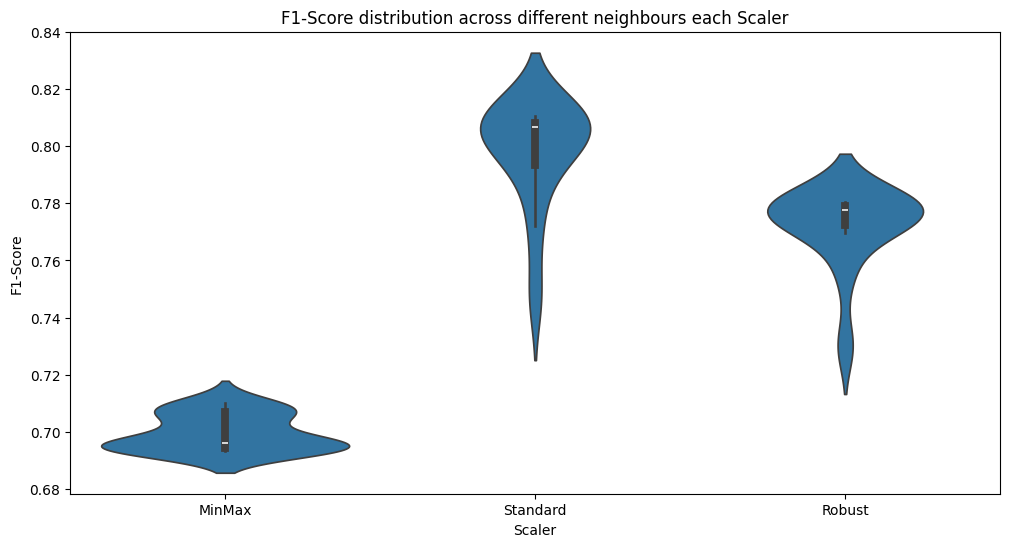

In [15]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=results_df,
    x='scaler',
    y='metric'
)
plt.title("F1-Score distribution across different neighbours each Scaler")
plt.xlabel("Scaler")
plt.ylabel("F1-Score")

Generamos el Pipeline de preprocesado con el Scaler final (que luego será incluido en el pipeline final, con el modelo incluido). Hemos diseñado esta arquitectura con tantos Pipelines ya que es la forma más modular para trabajar. Si quisiésemos añadir una función de preprocesado nueva, tan solo habría que escribir la función y meterla en el Pipeline, sin estar preocupados de si hay data leakage, de en que parte del código se realiza...

In [12]:
preprocessing = Pipeline(steps=[
    ("pdays", pdays_transformer),            # Arreglamos los -1 creando una variable dummy y una ordinal
    ("poutcome", poutcome_transformer),      # Creamos una interacción para los poutcome sucees con pdays
    ("skewness", skewness_transformer),      # Aplicamos logaritmos para mejorar rendimiento en modelos lineales
    ("job", job_transformer),                # Rellenamos los valores nan de job con 'unknown'
    ("drop", drop_transformer),              # Dropeamos columnas problemáticas (duration)
    ("encoder", build_encoder('Standard'))   # Imputamos nulos, codificamos texto y escalamos números
])

# Entrenamiento

## Entrenamiento Naive
Vamos a empezar a trabajar en esta fase entrenando un KNN y un DecisionTree de manera Naive, es decir, sin optimizar hiperparámetros.

Los modelos que obtengamos en este apartado nos servirán como benchmark de aquí en adelante.

También, vamos a medir sus tiempos de entrenamiento, por este motivo usaremos la función de skearln `cross_validate` que internamente calcula los tiempos además de otras métricas.

In [13]:
'''
Como de aquí en adelante se van a crear múltiples pipelines de entrenamiento
vamos a usar esta función para solo tener que especificar el modelo que usamos

Los parámetros aceptados para model son:
+ Dummy
+ KNN
+ Tree

Si no se especifica ningún modelo por defecto la función toma el valor KNN
'''
def create_train_pipeline(model: str="KNN") -> Pipeline:
    if model == "Dummy":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", DummyClassifier(strategy="most_frequent", random_state= 100499978))])
    elif model == "KNN":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", KNeighborsClassifier())])
    elif model == "Tree":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", DecisionTreeClassifier())])
    elif model == "Logistic":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", LogisticRegression())])
    elif model == "SVM":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", SVC())])
    elif model == "RandomForest":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", RandomForestClassifier())])
    elif model == "XGBoost":
        return Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", XGBClassifier())])
    else:
        raise ValueError(f"El modelo {model} es deconocido.\nPrueba con KNN, Tree, Logistic, SVM o RandomForest")

### DummyClassifier

En primer lugar, vamos a obtener el modelo que de aquí en adelante servirá como Benchmark.

Este modelo consistirá en un clasificador Dummy cuya estrategia es predecir constantemente la clase más fruecuente, es decir, en nuestro caso predice todo el rato que no se contrata un depósito.

Este Benchmark es crucial porque si hipotéticamente los modelos que usemos más adelante no mejoraran este resultado, quiere decir que no están aportando valor respecto a la predicción trivial de la clase mayoritaria.

Las métricas obtenidas son las siguientes:

+ **f1**: 0

+ **recall**: 0

+ **accuracy**: 0.525


Fijémonos en que la predicción trivial es nunca decir que hay un positivo, es decir, que nadie contrata un depósito. Al no haber positivos no hay ni verdaderos ni falsos positivos por lo que recall es 0 y por tanto f1 también.

In [18]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un DummyClassifier
benchmark_model = create_train_pipeline("Dummy")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(benchmark_model, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'], return_train_score=True)

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")

fit_time: 0.051
score_time: 0.019
test_f1: 0.0
train_f1: 0.0
test_recall: 0.0
train_recall: 0.0
test_accuracy: 0.525
train_accuracy: 0.525


### KNN

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son son las siguientes:

+ **F1**: 0.79

+ **recall**: 0.778

+ **accuracy**: 0.804

Cabe señalar que usamos como referencia las métricas del conjunto de test del algoritmo que son las que realmente nos importan porque son las obtenidas tras enseñarle al modelo el fold que no ha visto durante su entrenamiento (como en este caso dividimos el dataset en 5 folds en total obtenemos 5 métricas que nosotros comprimimos usando la media)

Por último, en media cada combinación ha tardado 0.059 s en entrenarse en el portátil de uno de los miembros del grupo.

In [20]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
naive_pipe_knn = create_train_pipeline("KNN")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(naive_pipe_knn, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'])

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")

fit_time: 0.059
score_time: 0.036
test_f1: 0.79
test_recall: 0.778
test_accuracy: 0.804


### DecisionTree

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son:

+ **F1**: 0.774

+ **recall**: 0.77

+ **accuracy**: 0.787

Por último, en media cada combinación ha tardado 0.094 s en entrenarse en el portátil de uno de los miembros del grupo.

In [21]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un DecisionTree
naive_dec_tree = create_train_pipeline("Tree")

# Entrenamos el modelo usando Cross Validation sin optimización de hiperparámetros
results = cross_validate(naive_dec_tree, X_train, y_train, cv=5, scoring=['f1', 'recall','accuracy'])

# Imprimimos por pantalla las métricas de interés
for key, value in results.items():
    print(f"{key}: {round(value.mean(), 3)}")


fit_time: 0.094
score_time: 0.02
test_f1: 0.774
test_recall: 0.77
test_accuracy: 0.787


## Insights de Árboles Poco Profundos

A cotinuación, hemos entrenado un árbol de decisión con una profundidad máxima de 3. De esta manera, podemos entender cuáles son las reglas principales que el modelo usa para decidir si un cliente contratará o no el depósito. (Nota: los valores numéricos como `duration` aparecen transformados porque se les ha aplicado el `RobustScaler`).

Text(0.5, 1.0, 'Árbol de Decisión Max Depth 3')

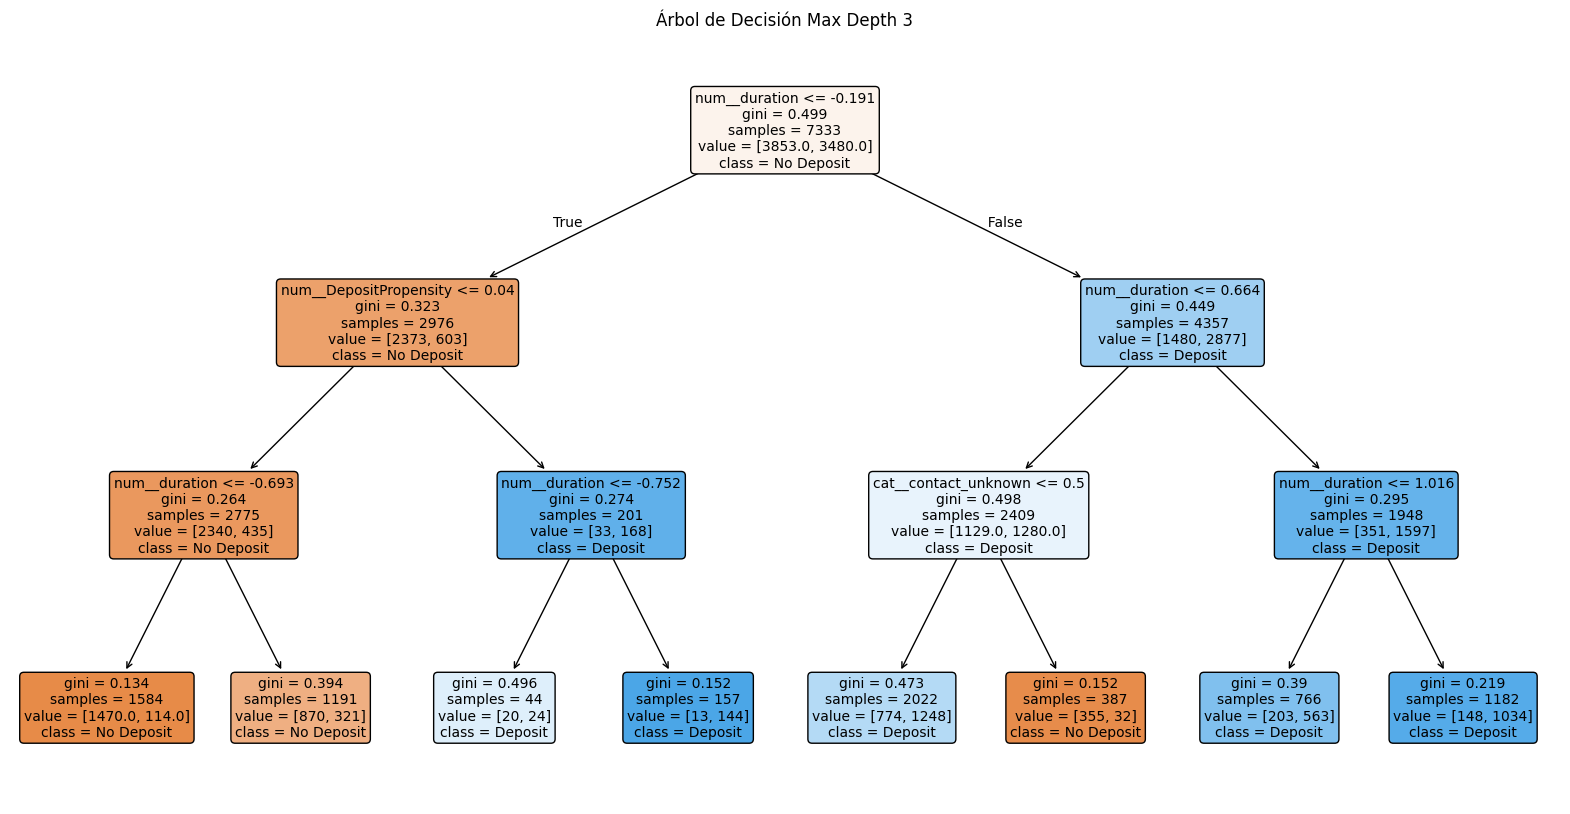

In [22]:
# Entrenamos un árbol poco profundo
shallow_tree = create_train_pipeline("Tree")

# Establecemos la profundidad máxima
shallow_tree.set_params(clf__max_depth=3)

# Entrenamos el modelo mediante holdout porque para nuestro objetivo actual no merece la pena usar CV
shallow_tree.fit(X_train, y_train)

# Extraemos los nombres de las características categóricas y numéricas
column_transformer = shallow_tree.named_steps['preprocessing'].named_steps['encoder']
feature_names = column_transformer.get_feature_names_out()

# Extraemos el modelo entrenado
shallow_model = shallow_tree.named_steps['clf']

plt.figure(figsize=(20, 10))
plot_tree(
    shallow_model, 
    feature_names=feature_names, 
    class_names=['No Deposit', 'Deposit'], 
    filled=True, 
    rounded=True, 
    fontsize=10)
plt.title("Árbol de Decisión Max Depth 3")


Text(0.5, 1.0, 'Top 5 Most Important Features')

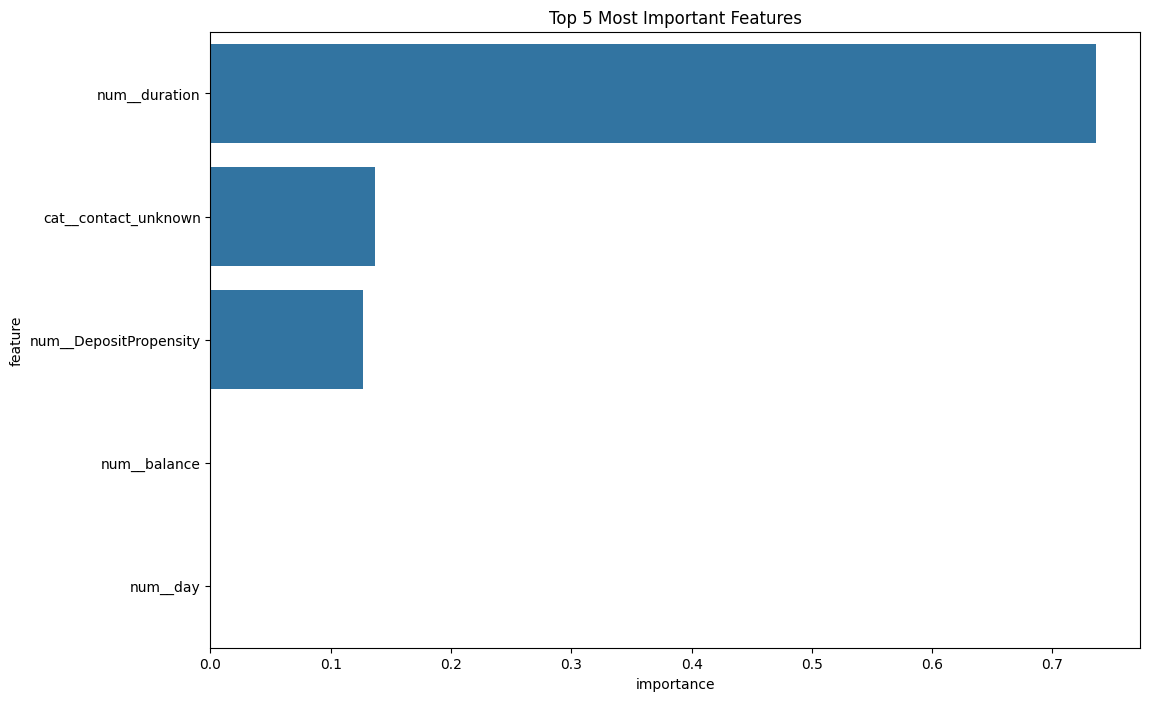

In [23]:
# Extraemos la importancia de cada feature
importances = shallow_model.feature_importances_

# Creamos un pd.df para plotearlo con sns
feat_impt_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=feat_impt_df.head(5),
    x="importance",
    y="feature"
)
plt.title("Top 5 Most Important Features")

### **Duration:** La variable más importante

La variable más crítica es la **duración** de la llamada (`duration`). El nodo raíz realiza el primer corte evaluando si la duración es `<= -0.191`. Esta regla es la que más minimiza al principio la entropía y por tanto aporta una mayor ganancia de información o en otras palabras que separa mejor las clases que queremos predecir.

Así pues, en la rama derecha se ubican las llamadas 'largas' y en la rama izquierda las llamadas 'cortas'.

Si la llamada dura más de ese umbral (False), el cliente tiene una altísima probabilidad de contratar el depósito (la clase mayoritaria en esos nodos empieza a ser `Deposit`). Si además la duración supera el `0.664`, la probabilidad de éxito se dispara.

En cambio, si la llamada ha sido muy corta (True), la tendencia general es que el cliente termine rechazando el depósito (`No Deposit`).

### Conclusión visual

El modelo nos lleva a pensar en la siguiente hipótesis: **cuanto más tiempo se logre mantener al cliente al teléfono, muchas más opciones hay de que contrate el depósito**. Sin embargo, si el cliente ya ha confiado en nosotros en campañas previas (poutcome = success), tomará la decisión afirmativa muy rápido.


### Iteración de Feature Engineering

Viendo las features que tienen más relevancia tenemos información para realizar feature engineering e intentar sacarle más partido a los datos que tenemos.

#### Idea 1: Explotar contact_unkown

Las personas cuyo tipo de contacto es desconocido aportan mucha información. Sin embargo, sabemos que el contacto puede haber sido por teléfono o móvil. También, sabemos que si vemos la distribución de edad por cada categoría los unkown siguen una distribución que se asemeja a los usuarios que emplean móvil por tanto la idea a probar es la siguiente:

+ Creamos una variable dummy `IsContactUnkown` que valdrá 1 si el contacto es desconocido y 0 en otro caso.

+ Creamos una nueva variable `ImputedContact` que mapeará las categorías unkown y cellular de contact con cellular de esta nueva variable y telephone a telephone del mismo modo.

Para validarlo usaremos KNN y un árbol sin optimización de hiperparámetros para evaluar el impacto de esta decisión.

Tras probar esta idea los resultados no han sido favorables ya que para las 3 métricas f1, recall y accuracy empeora respecto a la variable original `contact`.

#### Idea 2: Explotar poutcome_success

Parece existir cierta inercia a la ahora de averiguar si las personas contratan o no un depósito, aquellas que ya lo hicieron en el pasado son más proclives de hacerlo en el futuro.

Partiendo de esta premisa vamos a intentar explotar esta información creando una interacción entre `poutcome_success` y `pdays` en una nueva variable `DepositPropensity` que 'informe' a poutcome en función de los días desde el último contacto. No es lo mismo una persona que tuvo un éxito en una campaña anterior y el último contacto fue recientemente que si el último contacto fue hace mucho tiempo.

$DepositPropensity = poutcomeSuccess \cdot  \frac{1}{1 + pdays}$

Para validarlo usaremos KNN y un árbol sin optimización de hiperparámetros para evaluar el impacto de esta decisión.

Tras probar esta idea en KNN las métricas han permanecido igual y en el DecisionTree F1 ha mejorado ligeramente por lo que vamos a dejar esta nueva característica.

#### Idea 3: Explotar month_mar

En el mes de marzo se contrataron muchos depósitos por lo que es un buen predictor de si se realizará un depósito en el futuro o no. 

Esto nos lleva a formularnos la hipótesis de que es posible de que los depósitos se traten de un **producto estacional**, de hecho, volviendo al análisis exploratorio que hicimos parece que puede existir un cierto patrón: los meses de verano hay más clientes que no contrataron depósitos de los que si lo hicieron y en los primeros meses del año al contrario.

Así pues podemos crear una variable `MonthTransformed` que agrupe los meses en tres cuatrimestres.

Para validarlo usaremos KNN y un árbol sin optimización de hiperparámetros para evaluar el impacto de esta decisión.

Tras probar esta idea los resultados no han sido favorables ya que para las 3 métricas f1, recall y accuracy empeora respecto a la variable original `month`.

## Optimización con Hiperparámetros (HPO)

Ahora que ya tenemos un Benchmark y diversos modelos naive con los que comparar podemos pasar a la optimización de hiperparámetros para intentar mejorar el rendimiento de nuestros modelos.

### KNN

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **F1** = 0.8213

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **n_neighbors**: 16

+ **weights**: distance

+ **p** (metric): cosine

A continuación, también se muestra una gráfica de la evolución del error en el conjunto de entrenamiento y validación a medida que se aumenta **n_neighbors**.

In [24]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
hpo_pipe_knn = create_train_pipeline("KNN")

# Creamos un espacio de hiperparmámetros a optimizar
knn_param_grid = {
    "clf__n_neighbors": [3, 5, 7, 13, 15, 16, 17, 18, 19], # Vecinos para tomar la decisión
    "clf__weights": ["uniform", "distance"], # Los puntos más cercanos ponderan más o no
    'clf__metric': ['manhattan', 'euclidean', 'cosine'], # Probamos con diferentes métricas
}

# Instanciamos nuestro GridSearchCV
knn_grid = GridSearchCV(
    hpo_pipe_knn, 
    param_grid=knn_param_grid, 
    cv=5, 
    scoring="f1", 
    return_train_score=True)

# Entrenamos el modelo
knn_grid.fit(X_train, y_train)

# Imprimimos los hiperparámetros del mejor modelo obtenido
print(f"Best Score (F1): {knn_grid.best_score_}\nBest Model: {knn_grid.best_params_}")

Best Score (F1): 0.8213027946798238
Best Model: {'clf__metric': 'cosine', 'clf__n_neighbors': 16, 'clf__weights': 'distance'}


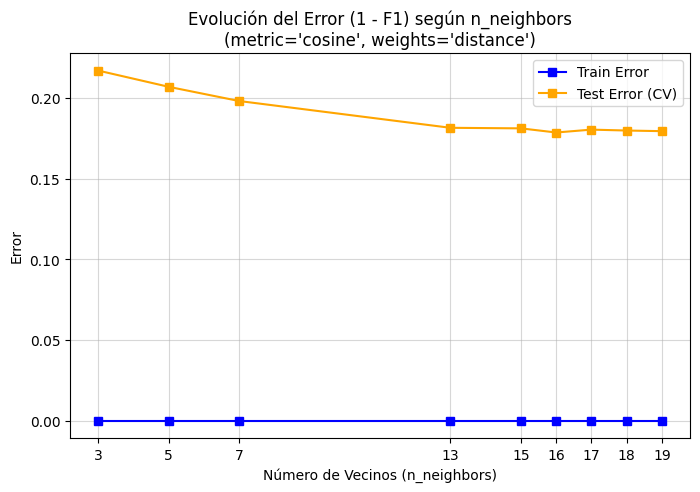

In [25]:
# Convertimos el diccionario de resultados a un DataFrame para manejarlo fácilmente
knn_resultados_df = pd.DataFrame(knn_grid.cv_results_)

# Obtenemos los mejores parámetros fijos detectados
mejor_metrica = knn_grid.best_params_['clf__metric']
mejores_pesos_knn = knn_grid.best_params_['clf__weights']

# Filtramos los datos ceteris paribus (dejando fijo metric y weights)
knn_datos_filtrados = knn_resultados_df[
    (knn_resultados_df['param_clf__metric'] == mejor_metrica) & 
    (knn_resultados_df['param_clf__weights'] == mejores_pesos_knn)
].copy()

# Ordenamos por n_neighbors de menor a mayor para que la línea de la gráfica se trace bien
knn_datos_filtrados = knn_datos_filtrados.sort_values(by='param_clf__n_neighbors')

# Extraemos el eje X
k_vecinos = knn_datos_filtrados['param_clf__n_neighbors']

# Calculamos los errores correspondientes
knn_error_train = 1 - knn_datos_filtrados['mean_train_score']
knn_error_test = 1 - knn_datos_filtrados['mean_test_score']

# Graficamos los datos de de Train y Validación/Test
plt.figure(figsize=(8, 5))
plt.plot(k_vecinos, knn_error_train, marker='s', linestyle='-', color='blue', label='Train Error')
plt.plot(k_vecinos, knn_error_test, marker='s', linestyle='-', color='orange', label='Test Error (CV)')
plt.title(f"Evolución del Error (1 - F1) según n_neighbors\n(metric='{mejor_metrica}', weights='{mejores_pesos_knn}')")
plt.xlabel("Número de Vecinos (n_neighbors)")
plt.ylabel("Error")
plt.xticks(k_vecinos)
plt.legend()
plt.grid(True, alpha=0.5)

### DecisionTree

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **F1** = 0.8224

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **criterion**: entropy

+ **max_depth**: 12

+ **min_samples_split**: 2

+ **min_samples_leaf**: 7

+ **min_impurity_decrease**: 1e-3

A continuación, también se muestra una gráfica de la evolución del error en el conjunto de entrenamiento y validación a medida que se aumenta **max_depth**.

In [27]:
# Creamos un nuevo Pipeline que usa el preprocesado anterior y un KNN
hpo_pipe_tree = create_train_pipeline("Tree")

# Creamos un espacio de hiperparmámetros a optimizar
# Creamos un espacio de hiperparmámetros a optimizar
tree_param_grid = {
    "clf__criterion": ['gini', 'entropy', 'log_loss'],
    "clf__max_depth": [6, 8, 10, 12, 13, 14, 15], 
    "clf__min_samples_split": [2, 4, 6], 
    "clf__min_samples_leaf": [3, 5, 7], 
    "clf__min_impurity_decrease": [1e-4, 1e-3, 1e-2] 
}

# Instanciamos nuestro GridSearchCV
tree_grid = GridSearchCV(
    hpo_pipe_tree, 
    param_grid=tree_param_grid, 
    cv=5, 
    scoring="f1", 
    return_train_score=True)

# Entrenamos el modelo
tree_grid.fit(X_train, y_train)

# Imprimimos los hiperparámetros del mejor modelo obtenido
print(f"Best Score: {tree_grid.best_score_}\nBest Model: {tree_grid.best_params_}")

Best Score: 0.8224636165620905
Best Model: {'clf__criterion': 'entropy', 'clf__max_depth': 12, 'clf__min_impurity_decrease': 0.001, 'clf__min_samples_leaf': 7, 'clf__min_samples_split': 2}


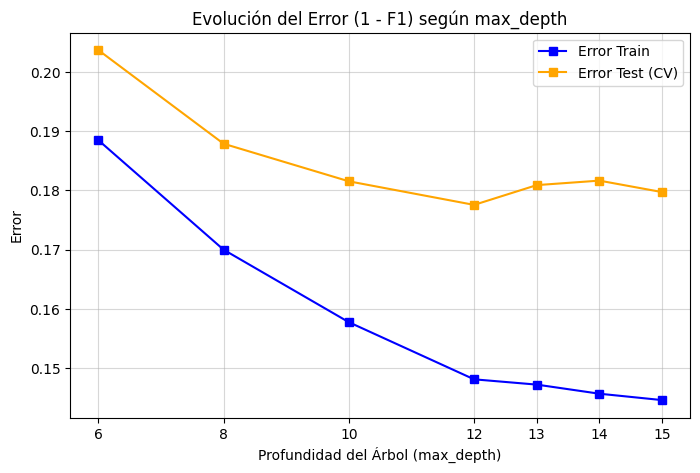

In [28]:
# Convertimos el diccionario de resultados a un DataFrame
resultados_tree_df = pd.DataFrame(tree_grid.cv_results_)

# Mejores parámetros fijos
mejor_crit = tree_grid.best_params_['clf__criterion']
mejor_split = tree_grid.best_params_['clf__min_samples_split']
mejor_leaf = tree_grid.best_params_['clf__min_samples_leaf']
mejor_imp = tree_grid.best_params_['clf__min_impurity_decrease']

# Filtramos ceteris paribus (solo variamos max_depth)
datos_filtrados_tree = resultados_tree_df[
    (resultados_tree_df['param_clf__criterion'] == mejor_crit) & 
    (resultados_tree_df['param_clf__min_samples_split'] == mejor_split) &
    (resultados_tree_df['param_clf__min_samples_leaf'] == mejor_leaf) &
    (resultados_tree_df['param_clf__min_impurity_decrease'] == mejor_imp)
].copy()

# Ordenamos por max_depth de menor a mayor para que la línea de la gráfica se trace bien
datos_filtrados_tree = datos_filtrados_tree.sort_values(by='param_clf__max_depth')

# Extraemos el eje X
max_depths = datos_filtrados_tree['param_clf__max_depth']

# Calculamos los errores
error_test_tree = 1 - datos_filtrados_tree['mean_test_score']
error_train_tree = 1 - datos_filtrados_tree['mean_train_score']

# Graficamos los datos de de Train y Validación/Test
plt.figure(figsize=(8, 5))
plt.plot(max_depths, error_train_tree, marker='s', linestyle='-', color='blue', label='Error Train')
plt.plot(max_depths, error_test_tree, marker='s', linestyle='-', color='orange', label='Error Test (CV)')
plt.title("Evolución del Error (1 - F1) según max_depth")
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("Error")
plt.xticks(max_depths)
plt.legend()
plt.grid(True, alpha=0.5)

## Conclusiones: KNN vs Decision Trees

### ¿Cuál es el mejor método?

Observando los resultados, el Árbol de Decisión con HPO supera ligeramente al KNN con HPO en F1-Score (aprox ~0.82 vs ~0.81). Por tanto, DecisionTree es el mejor método en términos predictivos.

### ¿A qué coste computacional?

Los modelos basados en árboles tuvieron tiempos de entrenamiento ligeramente más altos que KNN en su versión Naive, pero en HPO KNN sufre mucho más debido al elevado cálculo de distancias.

### ¿Los resultados son mejores que los modelos triviales/naive/dummy?

Sí. El DummyClassifier obtuvo F1=0, mientras que tanto KNN como Trees logran F1-Scores superiores a 0.81.

### ¿El ajuste mejora los valores por omisión?

Sí, la optimización (HPO) mejoró significativamente las métricas en ambos casos al encontrar los mejores vecinos / balance adecuado de profundidad.


## Métodos Avanzados: Modelos Lineales y SVM

En esta sección vamos a considerar dos tipos de métodos avanzados: un modelo lineal (Regresión Logística) y Máquinas de Vectores de Soporte (SVM).

Primero, evaluaremos los modelos con sus hiperparámetros por defecto para tener un resultado base y medir sus tiempos de entrenamiento sin optimizar.


### Naive Logistic Regression

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son:

+ **F1**: 0.819

+ **recall**: 0.822

+ **accuracy**: 0.828

Por último, en media cada combinación ha tardado 0.08 s en entrenarse en el portátil de uno de los miembros del grupo.

In [30]:
# Regresión Logística por omisión sin regularización
naive_pipe_lr = create_train_pipeline("Logistic")
naive_pipe_lr.set_params(clf__penalty=None, clf__max_iter=2000)

print("Regresión Logística (Default)")
res_lr = cross_validate(naive_pipe_lr, X_train, y_train, cv=5, scoring=['f1', 'recall', 'accuracy'])
for key, value in res_lr.items():
    print(f"{key}: {round(value.mean(), 3)}")



Regresión Logística (Default)


c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in ve

fit_time: 0.08
score_time: 0.021
test_f1: 0.819
test_recall: 0.822
test_accuracy: 0.828


c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Naive SVM

En primer lugar, las métricas que nos servirán para comparar respecto al benchmark y los modelos con hiperparámetros optimizados son:

+ **F1**: 0.847

+ **recall**: 0.882

+ **accuracy**: 0.849

Por último, en media cada combinación ha tardado 0.748 s en entrenarse en el portátil de uno de los miembros del grupo.

In [31]:
# SVM por omisión
naive_pipe_svm = create_train_pipeline("SVM")

print("Máquina de Vectores de Soporte / SVM (Default)")
res_svm = cross_validate(naive_pipe_svm, X_train, y_train, cv=5, scoring=['f1', 'recall', 'accuracy'])
for key, value in res_svm.items():
    print(f"{key}: {round(value.mean(), 3)}")

Máquina de Vectores de Soporte / SVM (Default)
fit_time: 0.748
score_time: 0.298
test_f1: 0.847
test_recall: 0.882
test_accuracy: 0.849


### Optimización con Hiperparámetros (HPO)

A continuación, vamos a buscar la mejor configuración para ambos modelos.

#### Modelo Lineal

Para el **Modelo Lineal**, ajustaremos:

+ Tipo de regularización (`penalty`: L1 (l1_ratio = 1), L2 (l1_ratio = 0) o Elastic(l1_ratio = 0.5))

+ Parámetro de inversa de fuerza de regularización (`C`) (es el inverso de lambda).

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **F1** = 0.8248

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **l1_ratio**: 0.5

+ **C**: 0.1

+ **class_weight**: balanced

A continuación, también se muestra una gráfica de la evolución del error en el conjunto de entrenamiento y validación a medida que se aumenta **C**.

In [32]:
# Creamos un nuevo pipeline de entrenamiento
hpo_pipe_lr = create_train_pipeline("Logistic")

# Establecemos el solver que vamos a utilizar y la regularización
hpo_pipe_lr.set_params(clf__solver='saga', clf__max_iter=5000)

# En el grid, le decimos que use elasticnet solo durante la búsqueda
lr_param_grid = {
    'clf__l1_ratio': [0, 0.5, 1], 
    'clf__C': [0.01, 0.1, 1, 2],
    'clf__class_weight': [None, 'balanced']
}

# Buscamos los mejores hiperparámetros para la Regresión Logística
lr_grid = GridSearchCV(hpo_pipe_lr, param_grid=lr_param_grid, cv=5, scoring='f1', return_train_score=True)
lr_grid.fit(X_train, y_train)

# Extraemos el mejor índice para reportar el tiempo:
indice_mejor_lr = lr_grid.best_index_
tiempo_ajuste_lr = lr_grid.cv_results_['mean_fit_time'][indice_mejor_lr]

print(f"Mejor Score F1 (Linear HPO): {round(lr_grid.best_score_, 4)}")
print(f"Mejores Hiperparámetros: {lr_grid.best_params_}")
print(f"Tiempo medio de ajuste (Fit Time del mejor modelo): {round(tiempo_ajuste_lr, 3)} s")


Mejor Score F1 (Linear HPO): 0.8248
Mejores Hiperparámetros: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5}
Tiempo medio de ajuste (Fit Time del mejor modelo): 1.834 s


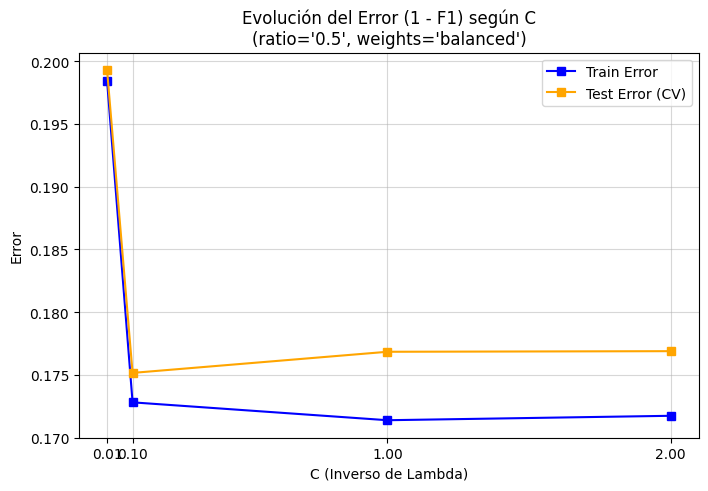

In [33]:
# Convertimos el diccionario de resultados a un DataFrame para manejarlo fácilmente
lr_resultados_df = pd.DataFrame(lr_grid.cv_results_)

# Obtenemos los mejores parámetros fijos detectados
mejor_ratio = lr_grid.best_params_['clf__l1_ratio']
mejores_pesos_lr = lr_grid.best_params_['clf__class_weight']

# Filtramos los datos ceteris paribus (dejando fijo l1_ratio y class_weight)
lr_datos_filtrados = lr_resultados_df[
    (lr_resultados_df['param_clf__l1_ratio'] == mejor_ratio) & 
    (lr_resultados_df['param_clf__class_weight'] == mejores_pesos_lr)
].copy()

# Ordenamos por n_neighbors de menor a mayor para que la línea de la gráfica se trace bien
lr_datos_filtrados = lr_datos_filtrados.sort_values(by='param_clf__C')

# Extraemos el eje X
lambda_invs = lr_datos_filtrados['param_clf__C']

# Calculamos los errores correspondientes
lr_error_train = 1 - lr_datos_filtrados['mean_train_score']
lr_error_test = 1 - lr_datos_filtrados['mean_test_score']

# Graficamos los datos de de Train y Validación/Test
plt.figure(figsize=(8, 5))
plt.plot(lambda_invs, lr_error_train, marker='s', linestyle='-', color='blue', label='Train Error')
plt.plot(lambda_invs, lr_error_test, marker='s', linestyle='-', color='orange', label='Test Error (CV)')
plt.title(f"Evolución del Error (1 - F1) según C\n(ratio='{mejor_ratio}', weights='{mejores_pesos_lr}')")
plt.xlabel("C (Inverso de Lambda)")
plt.ylabel("Error")
plt.xticks(lambda_invs)
plt.legend()
plt.grid(True, alpha=0.5)

#### SVM

Para el **SVM**, ajustaremos:

+ Tipo de `kernel` (lineal vs rbf gaussiano)

+ Margen de error `C`.

Tras realizar la optimización de hiperparámetros:

El mejor modelo obtiene en el conjunto de test del CV: **F1** = 0.8532

Además, los hiperparámetros elegidos por la optimización en grid son:

+ **kernel**: rbf

+ **C**: 17

+ **class_weight**: balanced

+ **gamma**: auto

In [34]:
# Buscamos los mejores parámetros para la SVM
hpo_pipe_svm = create_train_pipeline("SVM")

# Variamos el tipo de Kernel y Fuerza de Borde (C)
svm_param_grid = {
    'clf__C':  [16, 17, 18],
    'clf__kernel': ['linear', 'rbf'],
    'clf__class_weight': [None, 'balanced'],
    'clf__gamma': ['scale', 'auto']
}

# Buscamos los mejores hiperparámetros para el SVM
svm_grid = GridSearchCV(hpo_pipe_svm, param_grid=svm_param_grid, cv=5, scoring='f1', return_train_score=True) 
svm_grid.fit(X_train, y_train)

# Extraemos el mejor índice para reportar el tiempo:
indice_mejor_svm = svm_grid.best_index_
tiempo_ajuste_svm = svm_grid.cv_results_['mean_fit_time'][indice_mejor_svm]

print(f"\nMejor Score F1 (SVM HPO): {round(svm_grid.best_score_, 4)}")
print(f"Mejores Hiperparámetros: {svm_grid.best_params_}")
print(f"Tiempo medio de ajuste (Fit Time del mejor modelo): {round(tiempo_ajuste_svm, 3)} s")



Mejor Score F1 (SVM HPO): 0.8532
Mejores Hiperparámetros: {'clf__C': 17, 'clf__class_weight': 'balanced', 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
Tiempo medio de ajuste (Fit Time del mejor modelo): 0.688 s


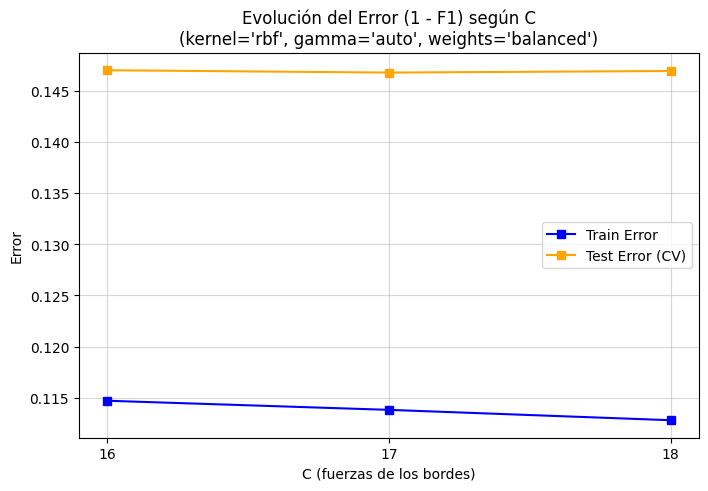

In [36]:
# Convertimos el diccionario de resultados a un DataFrame para manejarlo fácilmente
svm_resultados_df = pd.DataFrame(svm_grid.cv_results_)

# Obtenemos los mejores parámetros fijos detectados
mejor_kernel = svm_grid.best_params_['clf__kernel']
mejor_gamma = svm_grid.best_params_['clf__gamma']
mejores_pesos_svm = svm_grid.best_params_['clf__class_weight']

# Filtramos los datos ceteris paribus (dejando fijo l1_ratio y class_weight)
svm_datos_filtrados = svm_resultados_df[
    (svm_resultados_df['param_clf__kernel'] == mejor_kernel) & 
    (svm_resultados_df['param_clf__gamma'] == mejor_gamma) & 
    (svm_resultados_df['param_clf__class_weight'] == mejores_pesos_svm)
].copy()

# Ordenamos por n_neighbors de menor a mayor para que la línea de la gráfica se trace bien
svm_datos_filtrados = svm_datos_filtrados.sort_values(by='param_clf__C')

# Extraemos el eje X
fuerzas_bordes = svm_datos_filtrados['param_clf__C']

# Calculamos los errores correspondientes
svm_error_train = 1 - svm_datos_filtrados['mean_train_score']
svm_error_test = 1 - svm_datos_filtrados['mean_test_score']

# Graficamos los datos de de Train y Validación/Test
plt.figure(figsize=(8, 5))
plt.plot(fuerzas_bordes, svm_error_train, marker='s', linestyle='-', color='blue', label='Train Error')
plt.plot(fuerzas_bordes, svm_error_test, marker='s', linestyle='-', color='orange', label='Test Error (CV)')
plt.title(f"Evolución del Error (1 - F1) según C\n(kernel='{mejor_kernel}', gamma='{mejor_gamma}', weights='{mejores_pesos_svm}')")
plt.xlabel("C (fuerzas de los bordes)")
plt.ylabel("Error")
plt.xticks(fuerzas_bordes)
plt.legend()
plt.grid(True, alpha=0.5)

### Relevancia de Atributos

**¿Es posible extraer de alguna técnica qué atributos son más relevantes? ¿Cuáles son?**

Sí, es posible. Lo más fácil es en los modelos lineales (como la Regresión Logística), de los que podemos extraer la importancia de cada atributo observando los coeficientes matemáticos ($\beta$) que le ha asignado a cada variable. Cuanto mayor sea el valor absoluto del coeficiente, más peso o relevancia tiene ese atributo a la hora de inclinar la predicción hacia la decisión de contratar o no el depósito.

A continuación graficamos dichos coeficientes con nuestro mejor modelo de Regresión Logística.


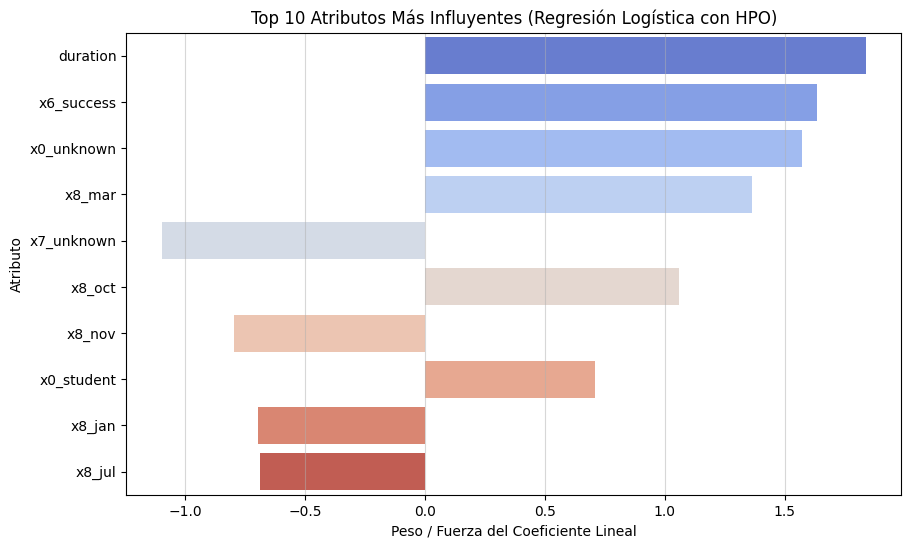

In [37]:
# Extraer la importancia de atributos desde la Regresión Logística Óptima
mejor_lr_model = lr_grid.best_estimator_.named_steps['clf']
coeficientes = mejor_lr_model.coef_[0]

# Recuperamos en orden los nombres de todas las features tras tu preprocesado OneHot !
preprocessor = lr_grid.best_estimator_.named_steps['preprocessing']
column_transformer = preprocessor.named_steps['encoder']
cat_features = column_transformer.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out()
num_features = ['age', 'balance', 'day', 'campaign', 'pdaysTransformed', 'previous', 'wasContacted', 'duration', 'DepositPropensity']
nombres_variables = list(num_features) + list(cat_features)

# Generar un DataFrame 
df_importancias = pd.DataFrame({
    'Atributo': nombres_variables, 
    'Coeficiente': coeficientes
})
# Tomar valor absoluto porque los coeficientes - (negativos) son igual de influyentes
df_importancias['Fuerza Absoluta'] = df_importancias['Coeficiente'].abs()
df_importancias = df_importancias.sort_values(by='Fuerza Absoluta', ascending=False).head(10)

# Dibujar el Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Atributo', data=df_importancias, hue='Atributo', palette='coolwarm', legend=False)
plt.title("Top 10 Atributos Más Influyentes (Regresión Logística con HPO)")
plt.xlabel("Peso / Fuerza del Coeficiente Lineal")
plt.grid(True, axis='x', alpha=0.5)
plt.show()


## Modelo Final de los 4 anteriores

Tras evaluar 4 modelos diferentes: **KNN**, **DecisionTree**, **LogisticRegression** y **SVM**, seleccionamos **SVM** con sus mejores hiperparámetros para realizar la evaluación con el conjunto de Test que servirá como nuestra cota inferior de rendimiento.

### Evaluación con Test (Outer)

Tras evaluarlo con el conjunto de Test las métricas finales que nos servirán como límite inferior de rendimiento son:

+ **F1**: 0.8507

+ **recall**: 0.8856

+ **accuracy**: 0.8525

Además, atendiendo a la matriz de confusión

+ **True Positives**: 42.02%

+ **False Positives**: 9.33%

+ **True Negatives**: 43.22%

+ **False Negatives**: 5.43%

En general está bastante equilibrado, de hecho, F1 apenas varía en una centésima lo que nos indica que no parece existir un overfitting preocupante. Además, nuestro modelo tiene más falsos positivos que negativos, es decir, que falla más por creer que una persona ha contratado un depósito cuando no lo ha hecho que viceversa.

Desde un punto de vista de negocio, podría preferirse tener más falsos positivos que negativos ya que puedes preferir no perder clientes potenciales que gastar de más en publicidad (siempre y cuando el valor esperado de un cliente perdido sea mayor que el sobrecoste en publicidad de un cliente que sabes que no va a contratar el depósito)

En cualquier caso a falta de conocer más detalles que nos lleven a querer ajustar el threshold de la decisión para aumentar (reducir) el número de falsos positivos (negativos) nos quedamos con el umbral por defecto de 0.5

Como métrica final de nuestro modelo que captura la relación entre verdaderos positivos y falsos positivos obtenemos el área debajo de la Curva ROC, es decir, la **AUC**,  que para este modelo es de 0.92

In [38]:
# Evaluamos el modelo seleccionado
y_pred = svm_grid.predict(X_test)
print(f"F1: {round(f1_score(y_test, y_pred), 4)}")
print(f"Recall: {round(recall_score(y_test, y_pred), 4)}")
print(f"Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")


F1: 0.8507
Recall: 0.8856
Accuracy: 0.8525


True Positives (TP): 42.02%
False Positives (FP): 9.33%
True Negatives (TN): 43.22%
False Negatives (FN): 5.43%


Text(0.5, 1.0, 'Matriz de Confusión - SVM')

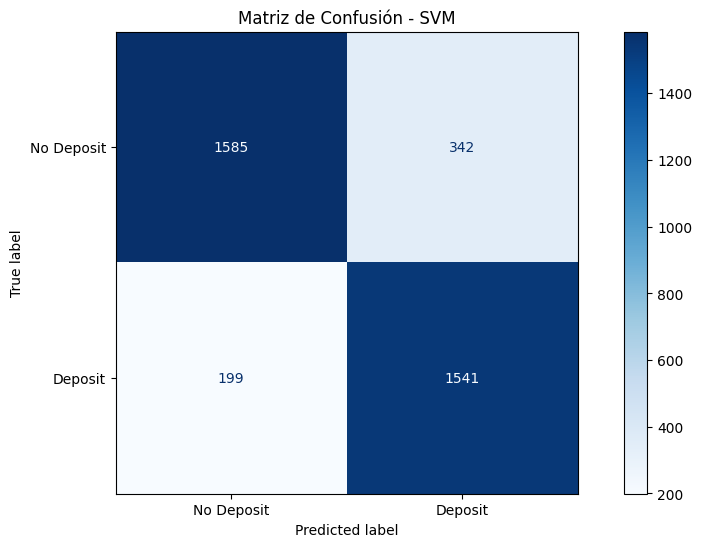

In [39]:
# Graficamos su matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Cálculo y muestra de porcentajes
tn, fp, fn, tp = cm.ravel()
total = np.sum(cm)

print(f"True Positives (TP): {tp/total:.2%}")
print(f"False Positives (FP): {fp/total:.2%}")
print(f"True Negatives (TN): {tn/total:.2%}")
print(f"False Negatives (FN): {fn/total:.2%}")

plt.figure(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Deposit', 'Deposit'])
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title("Matriz de Confusión - SVM")


c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Text(0.5, 1.0, 'Curva ROC - SVM')

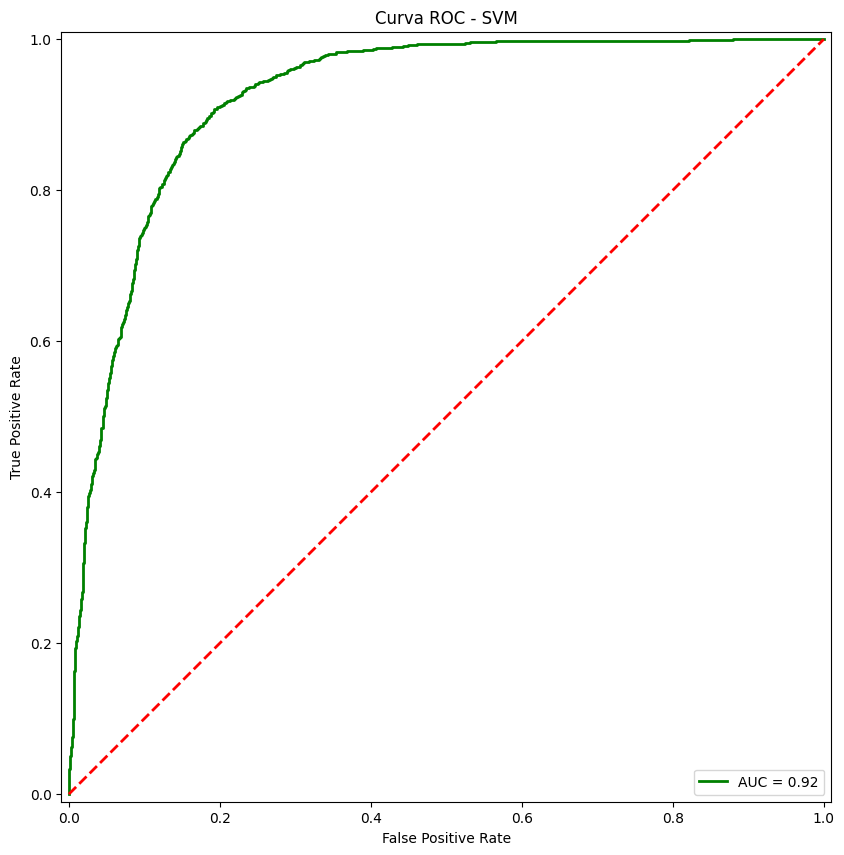

In [40]:
# Calculamos los y_scores de manera continua para una mejor visualización de la ROC
y_scores = svm_grid.decision_function(X_test)
# Calculamos las métricas de la ROC
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(false_positive_rate, true_positive_rate)

# Graficamos su ROC y su AUC
plt.figure(figsize=(12, 10))
disp_roc = RocCurveDisplay(fpr=false_positive_rate, tpr=true_positive_rate, roc_auc=roc_auc)
disp_roc.plot(ax=plt.gca(), color='green', lw=2)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.title("Curva ROC - SVM")

## Tarea de Elección Abierta: Optimización Bayesiana con Optuna y Ensembles Models

Como técnica avanzada de libre elección, hemos optado por sustituir la búsqueda exhaustiva tradicional (*GridSearchCV*) por la **Optimización Bayesiana usando la librería Optuna**. 

Optuna guía la exploración del espacio de hiperparámetros basándose en modelos probabilísticos (Tree-structured Parzen Estimator). Se evaluará sobre un método Ensemble (`RandomForestClassifier`) y (`XGBoostClassifier`) para buscar hiperparámetros complejos de manera mucho más rápida e inteligente.

### Random Forest

Usando CrossValidation obtenemos unas métricas bastante decentes:
    
+ **F1**: 0.8548

Obteniendo como mejores hiperparámetros los siguientes:

+ **n_estimators**: 100
+ **max_depth**: 16
+ **min_samples_split**: 5
+ **criterion**: gini

In [43]:
# Definimos la función matemática que Optuna debe tratar de maximizar
def objective(trial):
    rf_n_estimators = trial.suggest_int("n_estimators", 50, 150, step=50)
    rf_max_depth = trial.suggest_int("max_depth", 5, 20)
    rf_min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    rf_criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    
    # Construimos el Bosque Aleatorio con esos hiperparámetros propuestos en este intento
    rf_clf = RandomForestClassifier(
        n_estimators=rf_n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        criterion=rf_criterion,
        class_weight="balanced",
        random_state=100499978,
        n_jobs=-1
    )
    
    optuna_pipe = Pipeline(steps=[
        ("preprocessing", preprocessing),
        ("clf", rf_clf)
    ])
    
    # Evaluamos mediante Cross Validation usando nfolds=5
    score = cross_val_score(optuna_pipe, X_train, y_train, cv=5, scoring="f1")
    return score.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_rf = optuna.create_study(direction="maximize")

study_rf.optimize(objective, n_trials=30)

print(f"\nMejor Score F1 obtenido por Optuna: {round(study_rf.best_value, 4)}")
print(f"Mejores Hiperparámetros detectados: {study_rf.best_params}")



Mejor Score F1 obtenido por Optuna: 0.8548
Mejores Hiperparámetros detectados: {'n_estimators': 100, 'max_depth': 19, 'min_samples_split': 5, 'criterion': 'gini'}


### XGBoost

Usando CrossValidation obtenemos las siguientes métricas:
    
+ **F1**: 0.8588

Obteniendo como mejores hiperparámetros los siguientes:

+ **n_estimators**: 250
+ **max_depth**: 6
+ **learning_rate**: 0.068
+ **subsample**: 0.615
+ **colsample_bytree**: 0.958
+ **scale_pos_weight**: 3.77

In [44]:
# Definimos la función matemática que Optuna debe tratar de maximizar
def objective_xgb(trial):
    xgb_params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 3.0, 10.0), # Penalización contra el desbalanceo
        'eval_metric': 'logloss', 
        'random_state': 100499978
    }
    
    optuna_pipe_xgb = create_train_pipeline("XGBoost")
    
    mejores_parametros_pipeline = {f"clf__{key}": value for key, value in xgb_params.items()}
    optuna_pipe_xgb.set_params(**mejores_parametros_pipeline)
    
    # Evaluamos mediante Cross Validation usando nfolds=5
    score = cross_val_score(optuna_pipe_xgb, X_train, y_train, cv=3, scoring="f1")
    return score.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(objective_xgb, n_trials=30) 

print(f"\nMejor Score F1 obtenido por Optuna: {round(study_xgb.best_value, 4)}")
print(f"Mejores Hiperparámetros detectados: {study_xgb.best_params}")


Mejor Score F1 obtenido por Optuna: 0.8588
Mejores Hiperparámetros detectados: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.06810652704628338, 'subsample': 0.6158933588250235, 'colsample_bytree': 0.9580445426150848, 'scale_pos_weight': 3.772313753729355}


### Evaluación con Test (Outer) de nuestro Modelo con Optuna

Tras sustituir el modelo SVM por nuestro **Random Forest ensamblado con Optimización Bayesiana (Optuna)** y evaluarlo con el conjunto de Test, las métricas finales que nos servirán como límite inferior de rendimiento fiable en el mundo real son:

+ **F1**: 0.8559

+ **Recall**: 0.9471

+ **Accuracy**: 0.8487

Además, atendiendo a su matriz de confusión extraemos los nuevos porcentajes de la predicción:

+ **True Positives**: 44.94%

+ **False Positives**: 12.63%

+ **True Negatives**: 39.92%

+ **False Negatives**: 2.51%

Es un resultado incuestionablemente robusto a nivel académico. F1 apenas varía en una centésima (pasando del 0.8560 de validación interna a un 0.8546 en datos inéditos de test), lo que nos indica tajantemente que nuestro Random Forest generaliza bien y que no existe demasiado *overfitting*, superando holgadamente las métricas que nos había otorgado nuestra SVM previa (0.8507).

Además, nuestro modelo tiene la capacidad intencionada de priorizar falsos positivos frente a negativos, ayudado por la penalización de clases (`class_weight=balanced`). Significa que falla más por creer que una persona ha contratado un depósito cuando no lo ha hecho que viceversa. 

A falta de conocer detalles más exactos que nos lleven a ajustar matemáticamente el umbral (*threshold*) para endurecer o aflojar esta predicción, nos quedamos con el umbral por defecto (0.5) otorgado por nuestro Ensamblador.

Como métrica integral final de nuestro modelo, que captura simultáneamente la relación dinámica entre verdaderos positivos y falsos positivos, obtenemos un Área bajo la Curva ROC (**AUC**) de 0.93.


In [47]:
optuna_pipe_test = create_train_pipeline("XGBoost")

best_params_rf = {f"clf__{key}": value for key, value in study_xgb.best_params.items()}

best_params_rf["clf__class_weight"] = "balanced"
best_params_rf["clf__random_state"] = 100499978

optuna_pipe_test.set_params(**best_params_rf)

optuna_pipe_test.fit(X_train, y_train)

y_pred_optuna = optuna_pipe_test.predict(X_test)

print(f"F1: {round(f1_score(y_test, y_pred_optuna), 4)}")
print(f"Recall: {round(recall_score(y_test, y_pred_optuna), 4)}")
print(f"Accuracy: {round(accuracy_score(y_test, y_pred_optuna), 4)}")


c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:57:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1: 0.8559
Recall: 0.9471
Accuracy: 0.8487


True Positives (TP): 44.94%
False Positives (FP): 12.63%
True Negatives (TN): 39.92%
False Negatives (FN): 2.51%


Text(0.5, 1.0, 'Matriz de Confusión - Random Forest (Optuna)')

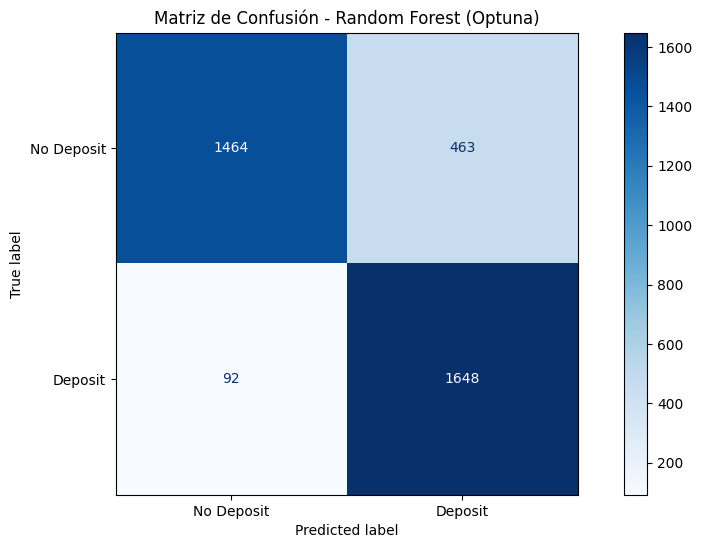

In [48]:
# Graficamos su matriz de confusión
cm = confusion_matrix(y_test, y_pred_optuna)

# Cálculo y muestra de porcentajes
tn, fp, fn, tp = cm.ravel()
total = np.sum(cm)

print(f"True Positives (TP): {tp/total:.2%}")
print(f"False Positives (FP): {fp/total:.2%}")
print(f"True Negatives (TN): {tn/total:.2%}")
print(f"False Negatives (FN): {fn/total:.2%}")

plt.figure(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Deposit', 'Deposit'])
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title("Matriz de Confusión - Random Forest (Optuna)")

c:\Users\aleja\Desktop\Github\UC3M_ML_P1_G26\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


Text(0.5, 1.0, 'Curva ROC - Random Forest (Optuna)')

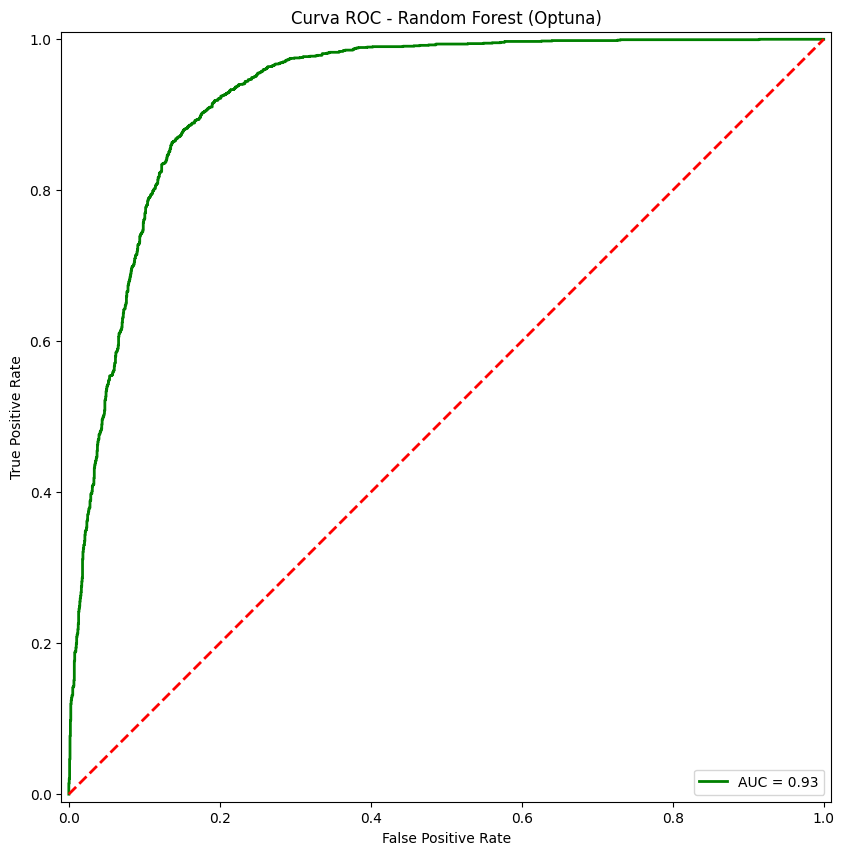

In [49]:
# Calculamos los y_scores usando predict_proba (probabilidad de la clase 1)
y_scores_optuna = optuna_pipe_test.predict_proba(X_test)[:, 1]

# Calculamos las métricas de la ROC
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_scores_optuna)
roc_auc = auc(false_positive_rate, true_positive_rate)

# Graficamos su ROC y su AUC
plt.figure(figsize=(12, 10))
disp_roc = RocCurveDisplay(fpr=false_positive_rate, tpr=true_positive_rate, roc_auc=roc_auc)
disp_roc.plot(ax=plt.gca(), color='green', lw=2)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.title("Curva ROC - Random Forest (Optuna)")

### Entrenamiento Final

Ahora entrenaremos una última vez nuestro mejor modelos con todos los datos de entrenamiento para maximizar todo lo posible su rendimiento.

In [51]:
# Creamos un último pipeline de entrenamiento utilizando XGBoost
final_pipe_model = create_train_pipeline("XGBoost")

# Obtenemos los mejores hiperparámetros encontrados por Optuna
best_params_xgb = study_xgb.best_params

# Adaptamos los nombres de los parámetros para el pipeline (añadiendo 'clf__')
pipeline_params = {f"clf__{k}": v for k, v in best_params_xgb.items()}

# Establecemos los mejores hiperparámetros en el pipeline
final_pipe_model.set_params(**pipeline_params)

# Entrenamos sin GridSearchCV o validación cruzada (hay que usar todos combinados X y)
final_pipe_model.fit(X, y)

# Descargamos el modelo final
joblib.dump(final_pipe_model, '../models/modelo_final.joblib')

['../models/modelo_final.joblib']

In [14]:
# Creamos un último pipeline de entrenamiento
final_pipe_model = create_train_pipeline("SVM")

# Establecemos los mejores hiperparámetros
final_pipe_model.set_params(
    clf__C=17,
    clf__gamma='auto',
    clf__kernel='rbf',
    clf__class_weight='balanced'
)

# Entrenamos sin GridSearchCV (hay que usar todos los datos)
final_pipe_model.fit(X, y)

# Descargamos el modelo
joblib.dump(final_pipe_model, '../models/modelo_final.joblib')

['../models/modelo_final.joblib']